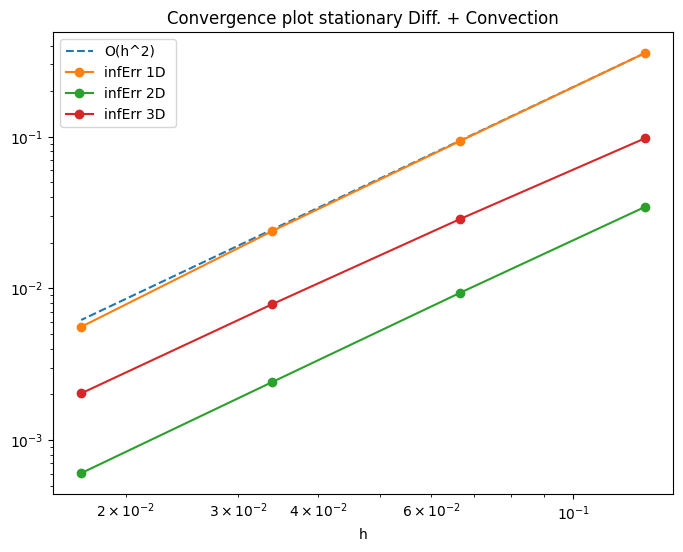

In [ ]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sympy as sp
import numpy as np
from FD import FDlapl_robin_sparse, rhs_robin, dir_mask_val, apply_dir
from scipy.sparse.linalg import bicgstab
from FD import FDconv_sparse, rhs_conv_robin

H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
Meth=[]
NN=[]
cond2=[]
cond3=[]


# Test Dir & Rob
alpha1 = {'L': 1, 'R': 1}
beta1 = {'L': 1, 'R': 1}
alpha2 = {'L': 0, 'R': 0, 'B': 0, 'T': 0}
beta2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}
alpha3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}
beta3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}

bx=1
by=2
bz=1

K=[4,5,6,7] # 7 :1:30min  approx. with bicgstab
for k in K: 
    N = 2**k
    M = N
    L=M
    a = 0.3
    b = 2.5
    c = 0.5
    d = 1.2
    l = 0
    m = 3
    hx = (b - a) / (N + 1)
    hy = (d - c) / (M + 1)
    hz = (m - l) / (L + 1)

    x_full = np.linspace(a, b, N + 2)
    y_full = np.linspace(c, d, M + 2)
    z_full = np.linspace(l, m, L + 2)

    X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
    Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')


    u1_true= np.sin(2 * np.pi * x_full)
    u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
    u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

    x, y, z = sp.symbols('x y z')
    u1_sym = sp.sin(2 * sp.pi * x)
    u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
    u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
    f1_sym = sp.diff(u1_sym, x, 2)+bx*sp.diff(u1_sym, x, 1)
    f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2) + bx*sp.diff(u2_sym, x, 1)+by*sp.diff(u2_sym, y, 1)
    f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)+bx*sp.diff(u3_sym, x, 1)+by*sp.diff(u3_sym, y, 1)+bz*sp.diff(u3_sym, z, 1)
    f1_func = sp.lambdify((x), f1_sym, 'numpy')
    f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
    f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')

    f1 = f1_func(x_full)
    f2 = f2_func(X_full, Y_full)
    f3 = f3_func(Xf, Yf, Zf)


    u1x = sp.diff(u1_sym, x, 1)
    u2x = sp.diff(u2_sym, x, 1)
    u2y = sp.diff(u2_sym, y, 1)
    u3x = sp.diff(u3_sym, x, 1)
    u3y = sp.diff(u3_sym, y, 1)
    u3z = sp.diff(u3_sym, z, 1)
    g1L=alpha1['L']*(-u1x)+beta1['L']*u1_sym; g1L=sp.lambdify((x), g1L, 'numpy')
    g1R=alpha1['R']*(u1x)+beta1['R']*u1_sym; g1R=sp.lambdify((x), g1R, 'numpy')
    g1={'L': g1L, 'R': g1R}
    g2L=alpha2['L']*(-u2x)+beta2['L']*u2_sym; g2L=sp.lambdify((x, y), g2L, 'numpy')
    g2R=alpha2['R']*(u2x)+beta2['R']*u2_sym; g2R=sp.lambdify((x, y), g2R, 'numpy')
    g2B=alpha2['B']*(-u2y)+beta2['B']*u2_sym; g2B=sp.lambdify((x, y), g2B, 'numpy')
    g2T=alpha2['T']*(u2y)+beta2['T']*u2_sym; g2T=sp.lambdify((x, y), g2T, 'numpy')
    g2={'L': g2L, 'R': g2R, 'B': g2B, 'T': g2T}
    g3L=alpha3['L']*(-u3x)+beta3['L']*u3_sym; g3L=sp.lambdify((x, y, z), g3L, 'numpy')
    g3R=alpha3['R']*(u3x)+beta3['R']*u3_sym; g3R=sp.lambdify((x, y, z), g3R, 'numpy')
    g3B=alpha3['B']*(-u3y)+beta3['B']*u3_sym; g3B=sp.lambdify((x, y, z), g3B, 'numpy')
    g3T=alpha3['T']*(u3y)+beta3['T']*u3_sym; g3T=sp.lambdify((x, y, z), g3T, 'numpy')
    g3D=alpha3['D']*(-u3z)+beta3['D']*u3_sym; g3D=sp.lambdify((x, y, z), g3D, 'numpy')
    g3U=alpha3['U']*(u3z)+beta3['U']*u3_sym; g3U=sp.lambdify((x, y, z), g3U, 'numpy')
    g3={'L': g3L, 'R': g3R, 'B': g3B, 'T': g3T, 'D': g3D, 'U': g3U}

    b1 = f1.ravel()
    b2 = f2.ravel()
    b3 = f3.ravel()

    A1   = FDlapl_robin_sparse(1, N, hx, alpha1, beta1)
    A2   = FDlapl_robin_sparse(2, N, hx, alpha2, beta2, M, hy)
    A3   = FDlapl_robin_sparse(3, N, hx, alpha3, beta3, M, hy, L, hz)

    B1=FDconv_sparse(1, N, hx, bx, alpha1, beta1)
    B2=FDconv_sparse(2, N, hx, bx, alpha2, beta2,M,hy,by)
    B3=FDconv_sparse(3, N, hx, bx, alpha3, beta3,M,hy,by,L,hz,bz)

    rhs1 = rhs_robin(1, f1, N, hx, alpha1, g1, x_full)
    rhs2 = rhs_robin(2, f2, N, hx, alpha2, g2, x_full, M, hy, y_full)
    rhs3 = rhs_robin(3, f3, N, hx, alpha3, g3, x_full, M, hy, y_full, L, hz, z_full)

    rhsC1=rhs_conv_robin(1, N, bx, alpha1, g1, x_full)
    rhsC2=rhs_conv_robin(2, N, bx, alpha2, g2, x_full,M, by, y_full)
    rhsC3=rhs_conv_robin(3, N, bx, alpha3, g3, x_full,M, by, y_full, L, bz,z_full)

    mask1, uD1 = dir_mask_val(1, N, alpha1, beta1, g1, x_full)
    mask2, uD2 = dir_mask_val(2, N, alpha2, beta2, g2, x_full, M, y_full)
    mask3, uD3 = dir_mask_val(3, N, alpha3, beta3, g3, x_full, M, y_full, L, z_full)

    A1d, rhs1d = apply_dir(A1, rhs1, mask1, uD1)
    A2d, rhs2d = apply_dir(A2, rhs2, mask2, uD2)
    A3d, rhs3d = apply_dir(A3, rhs3, mask3, uD3)

    B1d, rhs1dconv = apply_dir(B1, rhsC1, mask1, uD1)
    B2d, rhs2dconv = apply_dir(B2, rhsC2, mask2, uD2)
    B3d, rhs3dconv = apply_dir(B3, rhsC3, mask3, uD3)

    u1 = bicgstab(A1d+B1d, rhs1d+rhs1dconv)
    u2 = bicgstab(A2d+B2d, rhs2d+rhs2dconv)
    u3 = bicgstab(A3d+B3d, rhs3d+rhs3dconv)

    u1=u1[0]
    u2=u2[0].reshape(N+2,M+2)
    u3=u3[0].reshape(N+2,M+2,L+2)


    e1=np.max(np.abs(u1-u1_true)); E1.append(e1)
    e2=np.max(np.abs(u2-u2_true)); E2.append(e2)
    e3=np.max(np.abs(u3-u3_true)); E3.append(e3)
    NN.append(N)
    H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H, np.power(H,2)*(E1[0]/H[0]**2), '--', label='O(h^2)')
plt.loglog(H, E1, 'o-',  label='infErr 1D ')
plt.loglog(H, E2, 'o-',  label='infErr 2D ')
plt.loglog(H, E3, 'o-',  label='infErr 3D ')
plt.legend(); plt.xlabel('h')
plt.title('Convergence plot stationary Diff. + Convection')
plt.show()


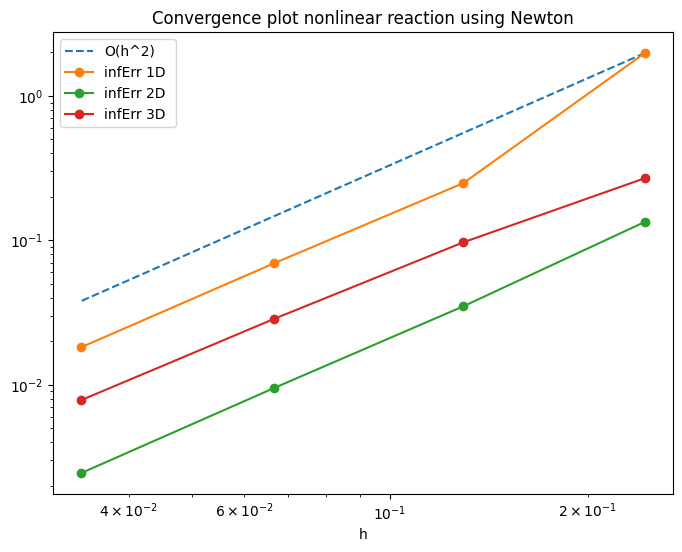

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sympy as sp
from FD import FDlapl_robin_sparse, rhs_robin, dir_mask_val, apply_dir
from FD import FDconv_sparse, rhs_conv_robin
from custom_solvers import newton_solver, quasi_newton_solver
from scipy.sparse import diags as spdiags


H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
Meth=[]
NN=[]
cond2=[]
cond3=[]

# Test Dir & Rob
alpha1 = {'L': 1, 'R': 1}
beta1 = {'L': 1, 'R': 1}
alpha2 = {'L': 0, 'R': 0, 'B': 0, 'T': 0}
beta2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}
alpha3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}
beta3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}

bx=1
by=2
bz=1

K=[3,4,5,6] # 3,4,5,6: takes 1:40min  approx. with newton
for k in K: 
    N = 2**k
    M = N
    L=M
    a = 0.3
    b = 2.5
    c = 0.5
    d = 1.2
    l = 0
    m = 3
    hx = (b - a) / (N + 1)
    hy = (d - c) / (M + 1)
    hz = (m - l) / (L + 1)

    x_full = np.linspace(a, b, N + 2)
    y_full = np.linspace(c, d, M + 2)
    z_full = np.linspace(l, m, L + 2)

    X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
    Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')


    u1_true= np.sin(2 * np.pi * x_full)
    u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
    u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

    x, y, z = sp.symbols('x y z')
    u1_sym = sp.sin(2 * sp.pi * x)
    u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
    u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
    def r(u):
        return u**2/(2+u)
    f1_sym = sp.diff(u1_sym, x, 2)+bx*sp.diff(u1_sym, x, 1) + r(u1_sym)
    f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2) + bx*sp.diff(u2_sym, x, 1)+by*sp.diff(u2_sym, y, 1) + r(u2_sym)
    f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)+bx*sp.diff(u3_sym, x, 1)+by*sp.diff(u3_sym, y, 1)+bz*sp.diff(u3_sym, z, 1) +r(u3_sym)
    f1_func = sp.lambdify((x), f1_sym, 'numpy')
    f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
    f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')

    f1 = f1_func(x_full)
    f2 = f2_func(X_full, Y_full)
    f3 = f3_func(Xf, Yf, Zf)

    u1x = sp.diff(u1_sym, x, 1)
    u2x = sp.diff(u2_sym, x, 1)
    u2y = sp.diff(u2_sym, y, 1)
    u3x = sp.diff(u3_sym, x, 1)
    u3y = sp.diff(u3_sym, y, 1)
    u3z = sp.diff(u3_sym, z, 1)
    g1L=alpha1['L']*(-u1x)+beta1['L']*u1_sym; g1L=sp.lambdify((x), g1L, 'numpy')
    g1R=alpha1['R']*(u1x)+beta1['R']*u1_sym; g1R=sp.lambdify((x), g1R, 'numpy')
    g1={'L': g1L, 'R': g1R}
    g2L=alpha2['L']*(-u2x)+beta2['L']*u2_sym; g2L=sp.lambdify((x, y), g2L, 'numpy')
    g2R=alpha2['R']*(u2x)+beta2['R']*u2_sym; g2R=sp.lambdify((x, y), g2R, 'numpy')
    g2B=alpha2['B']*(-u2y)+beta2['B']*u2_sym; g2B=sp.lambdify((x, y), g2B, 'numpy')
    g2T=alpha2['T']*(u2y)+beta2['T']*u2_sym; g2T=sp.lambdify((x, y), g2T, 'numpy')
    g2={'L': g2L, 'R': g2R, 'B': g2B, 'T': g2T}
    g3L=alpha3['L']*(-u3x)+beta3['L']*u3_sym; g3L=sp.lambdify((x, y, z), g3L, 'numpy')
    g3R=alpha3['R']*(u3x)+beta3['R']*u3_sym; g3R=sp.lambdify((x, y, z), g3R, 'numpy')
    g3B=alpha3['B']*(-u3y)+beta3['B']*u3_sym; g3B=sp.lambdify((x, y, z), g3B, 'numpy')
    g3T=alpha3['T']*(u3y)+beta3['T']*u3_sym; g3T=sp.lambdify((x, y, z), g3T, 'numpy')
    g3D=alpha3['D']*(-u3z)+beta3['D']*u3_sym; g3D=sp.lambdify((x, y, z), g3D, 'numpy')
    g3U=alpha3['U']*(u3z)+beta3['U']*u3_sym; g3U=sp.lambdify((x, y, z), g3U, 'numpy')
    g3={'L': g3L, 'R': g3R, 'B': g3B, 'T': g3T, 'D': g3D, 'U': g3U}

    b1 = f1.ravel()
    b2 = f2.ravel()
    b3 = f3.ravel()

    A1   = FDlapl_robin_sparse(1, N, hx, alpha1, beta1)
    A2   = FDlapl_robin_sparse(2, N, hx, alpha2, beta2, M, hy)
    A3   = FDlapl_robin_sparse(3, N, hx, alpha3, beta3, M, hy, L, hz)

    B1=FDconv_sparse(1, N, hx, bx, alpha1, beta1)
    B2=FDconv_sparse(2, N, hx, bx, alpha2, beta2,M,hy,by)
    B3=FDconv_sparse(3, N, hx, bx, alpha3, beta3,M,hy,by,L,hz,bz)

    rhs1 = rhs_robin(1, f1, N, hx, alpha1, g1, x_full)
    rhs2 = rhs_robin(2, f2, N, hx, alpha2, g2, x_full, M, hy, y_full)
    rhs3 = rhs_robin(3, f3, N, hx, alpha3, g3, x_full, M, hy, y_full, L, hz, z_full)

    rhsC1=rhs_conv_robin(1, N, bx, alpha1, g1, x_full)
    rhsC2=rhs_conv_robin(2, N, bx, alpha2, g2, x_full,M, by, y_full)
    rhsC3=rhs_conv_robin(3, N, bx, alpha3, g3, x_full,M, by, y_full, L, bz,z_full)

    mask1, uD1 = dir_mask_val(1, N, alpha1, beta1, g1, x_full)
    mask2, uD2 = dir_mask_val(2, N, alpha2, beta2, g2, x_full, M, y_full)
    mask3, uD3 = dir_mask_val(3, N, alpha3, beta3, g3, x_full, M, y_full, L, z_full)

    A1d, rhs1d = apply_dir(A1, rhs1, mask1, uD1)
    A2d, rhs2d = apply_dir(A2, rhs2, mask2, uD2)
    A3d, rhs3d = apply_dir(A3, rhs3, mask3, uD3)

    B1d, rhs1dconv = apply_dir(B1, rhsC1, mask1, uD1)
    B2d, rhs2dconv = apply_dir(B2, rhsC2, mask2, uD2)
    B3d, rhs3dconv = apply_dir(B3, rhsC3, mask3, uD3)


    def fun1d(u):
        react=r(u)
        react[mask1]=0
        return (A1d+B1d)@u+react-(rhs1d+rhs1dconv)
    def fun2d(u):
        react=r(u)
        react[mask2]=0
        return (A2d+B2d)@u+react-(rhs2d+rhs2dconv)
    def fun3d(u):
        react=r(u)
        react[mask3]=0
        return (A3d+B3d)@u+react-(rhs3d+rhs3dconv)
    

    def dr(u):   return (2*u * (2 + u)-u**2) / (2 + u)**2

    def jac1d(u):  
        dru=dr(u)
        dru[mask1]=0
        return A1d + B1d + spdiags(dru)
    def jac2d(u):  
        dru=dr(u)
        dru[mask2]=0
        return A2d + B2d + spdiags(dru)
    def jac3d(u):  
        dru=dr(u)
        dru[mask3]=0
        return A3d + B3d + spdiags(dru)

    u01=np.zeros_like(rhs1dconv)
    u02=np.zeros_like(rhs2dconv)
    u03=np.zeros_like(rhs3dconv)

    u1,_=newton_solver(u01, fun1d,jac1d, 1e-8, 10*len(u01))
    u2,_=newton_solver(u02, fun2d,jac2d, 1e-8, 5*len(u02))
    u3,_=newton_solver(u03, fun3d,jac3d, 1e-8, 3*len(u03))

    u1=u1
    u2=u2.reshape(N+2,M+2)
    u3=u3.reshape(N+2,M+2,L+2)

    e1=np.max(np.abs(u1-u1_true)); E1.append(e1)
    e2=np.max(np.abs(u2-u2_true)); E2.append(e2)
    e3=np.max(np.abs(u3-u3_true)); E3.append(e3)
    NN.append(N)
    H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H, np.power(H,2)*(E1[0]/H[0]**2), '--', label='O(h^2)')
plt.loglog(H, E1, 'o-',  label='infErr 1D ')
plt.loglog(H, E2, 'o-',  label='infErr 2D ')
plt.loglog(H, E3, 'o-',  label='infErr 3D ')
plt.legend(); plt.xlabel('h')
plt.title('Convergence plot nonlinear reaction using Newton')
plt.show()


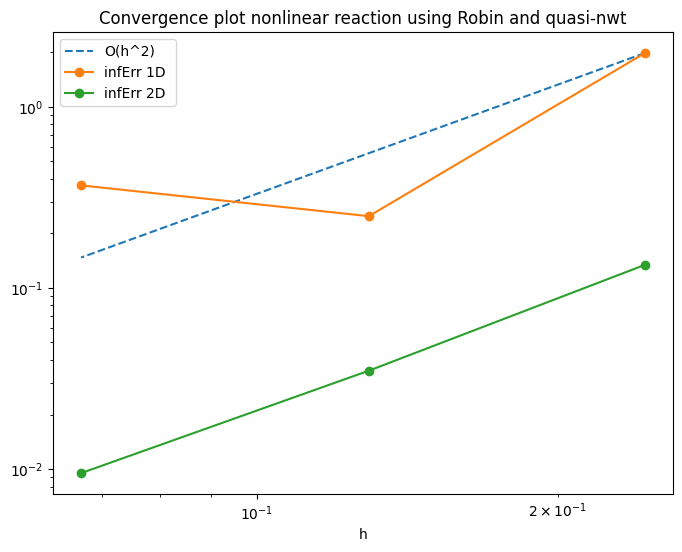

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sympy as sp
from FD import FDlapl_robin_sparse, rhs_robin, dir_mask_val, apply_dir
from FD import FDconv_sparse, rhs_conv_robin
from custom_solvers import quasi_newton_solver


H=[]
E1=[]
E2=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
Meth=[]
NN=[]

# Test Dir & Rob
alpha1 = {'L': 1, 'R': 1}
beta1 = {'L': 1, 'R': 1}
alpha2 = {'L': 0, 'R': 0, 'B': 0, 'T': 0}
beta2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}


bx=1
by=2

K=[3,4,5] # quasi newton is slower
for k in K: 
    N = 2**k
    M = N
    a = 0.3
    b = 2.5
    c = 0.5
    d = 1.2

    hx = (b - a) / (N + 1)
    hy = (d - c) / (M + 1)

    x_full = np.linspace(a, b, N + 2)
    y_full = np.linspace(c, d, M + 2)

    X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')


    u1_true= np.sin(2 * np.pi * x_full)
    u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)

    x, y, z = sp.symbols('x y z')
    u1_sym = sp.sin(2 * sp.pi * x)
    u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
    def r(u):
        return u**2/(2+u)
    f1_sym = sp.diff(u1_sym, x, 2)+bx*sp.diff(u1_sym, x, 1) + r(u1_sym)
    f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2) + bx*sp.diff(u2_sym, x, 1)+by*sp.diff(u2_sym, y, 1) + r(u2_sym)
    f1_func = sp.lambdify((x), f1_sym, 'numpy')
    f2_func = sp.lambdify((x, y), f2_sym, 'numpy')

    f1 = f1_func(x_full)
    f2 = f2_func(X_full, Y_full)

    u1x = sp.diff(u1_sym, x, 1)
    u2x = sp.diff(u2_sym, x, 1)
    u2y = sp.diff(u2_sym, y, 1)
    g1L=alpha1['L']*(-u1x)+beta1['L']*u1_sym; g1L=sp.lambdify((x), g1L, 'numpy')
    g1R=alpha1['R']*(u1x)+beta1['R']*u1_sym; g1R=sp.lambdify((x), g1R, 'numpy')
    g1={'L': g1L, 'R': g1R}
    g2L=alpha2['L']*(-u2x)+beta2['L']*u2_sym; g2L=sp.lambdify((x, y), g2L, 'numpy')
    g2R=alpha2['R']*(u2x)+beta2['R']*u2_sym; g2R=sp.lambdify((x, y), g2R, 'numpy')
    g2B=alpha2['B']*(-u2y)+beta2['B']*u2_sym; g2B=sp.lambdify((x, y), g2B, 'numpy')
    g2T=alpha2['T']*(u2y)+beta2['T']*u2_sym; g2T=sp.lambdify((x, y), g2T, 'numpy')
    g2={'L': g2L, 'R': g2R, 'B': g2B, 'T': g2T}
    
    b1 = f1.ravel()
    b2 = f2.ravel()

    A1   = FDlapl_robin_sparse(1, N, hx, alpha1, beta1)
    A2   = FDlapl_robin_sparse(2, N, hx, alpha2, beta2, M, hy)

    B1=FDconv_sparse(1, N, hx, bx, alpha1, beta1)
    B2=FDconv_sparse(2, N, hx, bx, alpha2, beta2,M,hy,by)

    rhs1 = rhs_robin(1, f1, N, hx, alpha1, g1, x_full)
    rhs2 = rhs_robin(2, f2, N, hx, alpha2, g2, x_full, M, hy, y_full)

    rhsC1=rhs_conv_robin(1, N, bx, alpha1, g1, x_full)
    rhsC2=rhs_conv_robin(2, N, bx, alpha2, g2, x_full,M, by, y_full)

    mask1, uD1 = dir_mask_val(1, N, alpha1, beta1, g1, x_full)
    mask2, uD2 = dir_mask_val(2, N, alpha2, beta2, g2, x_full, M, y_full)

    A1d, rhs1d = apply_dir(A1, rhs1, mask1, uD1)
    A2d, rhs2d = apply_dir(A2, rhs2, mask2, uD2)

    B1d, rhs1dconv = apply_dir(B1, rhsC1, mask1, uD1)
    B2d, rhs2dconv = apply_dir(B2, rhsC2, mask2, uD2)


    def fun1d(u):
        react=r(u)
        react[mask1]=0
        return (A1d+B1d)@u+react-(rhs1d+rhs1dconv)
    def fun2d(u):
        react=r(u)
        react[mask2]=0
        return (A2d+B2d)@u+react-(rhs2d+rhs2dconv)


    u01=np.zeros_like(rhs1dconv)
    u02=np.zeros_like(rhs2dconv)

    u1,_=quasi_newton_solver(u01, fun1d, 1e-8, 10*len(u01))
    u2,_=quasi_newton_solver(u02, fun2d, 1e-8, 7*len(u02))


    u1=u1
    u2=u2.reshape(N+2,M+2)

    e1=np.max(np.abs(u1-u1_true)); E1.append(e1)
    e2=np.max(np.abs(u2-u2_true)); E2.append(e2)
    NN.append(N)
    H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H, np.power(H,2)*(E1[0]/H[0]**2), '--', label='O(h^2)')
plt.loglog(H, E1, 'o-',  label='infErr 1D ')
plt.loglog(H, E2, 'o-',  label='infErr 2D ')
plt.legend(); plt.xlabel('h')
plt.title('Convergence plot nonlinear reaction using Robin and quasi-nwt')
plt.show()
